<a href="https://colab.research.google.com/github/abarbierif/IA_UBB/blob/Project/SIFT_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `SIFT CIFAR-10`
En este notebook se extrae el vector de características de un subconjunto de datos de `CIFAR-10` usando `SIFT`. En un principio se consideran 10 clases (total de clases) y luego se consideran solo 2 clases para analizar el desempeño en un problema menos complejo. Todos los vectores de características obtenidos son clasificados con `MLP` y `RFC`.

### `Librerias`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import sys
import pandas as pd
import pickle
import time
from tensorflow.keras.preprocessing.image import smart_resize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.cluster import KMeans
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import GlorotUniform, Zeros
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Accuracy, F1Score

os.chdir('/content/drive/MyDrive/AI/Project')
sys.path.append('/content/drive/MyDrive/AI/Project/py_utils')

from data_loading import *
from data_visualization import *
from utils import *
from data_preprocessing import *

#reproducibility (deterministic)
from tensorflow.keras.utils import set_random_seed
from tensorflow.config.experimental import enable_op_determinism

set_random_seed(1)
enable_op_determinism()

os.getcwd()

'/content/drive/MyDrive/AI/Project'

In [ ]:
os.listdir('./')

['results',
 'py_utils',
 'feature_vectors',
 'weights',
 'CNN_FashionMNIST.ipynb',
 'CNN_CIFAR10.ipynb',
 'SIFT_FashionMNIST.ipynb',
 'SIFT_CIFAR10.ipynb',
 'keypointsCIFAR10.pdf']

### `Cargar Dataset`

In [ ]:
X, y = load_data(
    source='tfds',
    to='ndarray',
    dataset='cifar10',
    dims=(32,32)
)

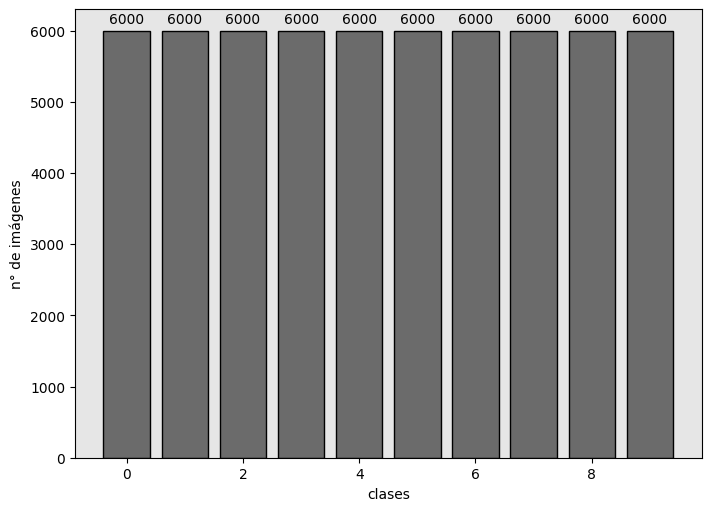

In [ ]:
classes_distribution(
    y,
    figsize=(7,5),
    title='',
    hatch='',
    cmap=None,
    xlabel='clases',
    ylabel='n° de imágenes',
    labelrotation=0,
    facecolor='#e6e6e6',
    color='#6b6b6b'
)

### `Funciones`

In [ ]:
def testing_data(X, Y, samples_per_class):

    '''
    Esta función selecciona un subconjunto balanceado de datos de un conjunto de datos mayor, asegurando que haya un número igual de muestras para cada clase.

    Los datos seleccionados se utilizan para fines de prueba o evaluación, y la función también imprime la forma de los datos resultantes y un gráfico de la distribución de clases.

    Parámetros:
        X: Conjunto de imágenes o datos (ndarray).
        Y: Etiquetas correspondientes a las imágenes o datos (ndarray).
        samples_per_class: Número de muestras a seleccionar por cada clase.

    Retorna:
        X: Subconjunto de datos seleccionados (ndarray).
        Y: Etiquetas correspondientes al subconjunto de datos (ndarray).
    '''

    if samples_per_class > np.max(np.unique(Y, return_counts=True)[1]):
        raise ValueError(f"samples_per_class must be less than {np.max(np.unique(Y, return_counts=True)[1])}")

    for _ in np.unique(Y):
        X = np.delete(X, np.argwhere(Y == _)[samples_per_class:], axis=0)
        Y = np.delete(Y, np.argwhere(Y == _)[samples_per_class:], axis=0)

    print(f"X shape: {X.shape}, Y shape: {Y.shape}")
    classes_distribution(Y, figsize=(7,5), title='', hatch='', cmap=None, xlabel='clases', ylabel='n° de imágenes', labelrotation=0, facecolor='#e6e6e6', color='#6b6b6b')

    return X, Y

In [ ]:
def train_predict(x=None, y=None, classifier=None, classes=None, weights_path=None, write_file=None):

    '''
    Esta función entrena un clasificador ('rfc' o 'mlp') utilizando validación cruzada estratificada con 5 folds
    y evalúa su rendimiento en términos de precisión (accuracy) y F1-score ponderado.

    Los resultados de cada fold y las medias se almacenan en un DataFrame y, opcionalmente, se guardan en un archivo.

    Parámetros:
        x: Vectores de características (ndarray).
        y: Etiquetas (ndarray).
        classifier: Tipo de clasificador a utilizar ('rfc' para RandomForestClassifier o 'mlp' para un perceptrón multicapa).
        classes: Número de clases (requerido para 'mlp').
        weights_path: Ruta para guardar los pesos del modelo 'mlp' (opcional).
        write_file: Ruta para guardar el DataFrame con los resultados (opcional).

    Retorna:
        None. (Los resultados se almacenan en un DataFrame y se guardan en un archivo si se especifica 'write_file'.)

    '''

    if classifier not in ['rfc', 'mlp']:
        raise ValueError("classifier must be 'rfc' or 'mlp'")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    df = pd.DataFrame(columns=['','accuracy', 'f1_weighted'])

    for n, (train_idx, test_idx) in enumerate(skf.split(x, y)):

        if classifier == 'rfc':
            clf = RandomForestClassifier(n_estimators=500, random_state=42)
            clf.fit(x[train_idx], y[train_idx])

            y_pred = clf.predict(x[test_idx])
            accuracy = accuracy_score(y[test_idx], y_pred)
            f1 = f1_score(y[test_idx], y_pred, average='weighted')

            df.loc[len(df)] = ['',accuracy, f1]

        elif classifier == 'mlp':

            dimdin = x.shape[1]

            clf = Sequential()
            clf.add(Dense(256, input_dim=dimdin, activation='relu', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))
            clf.add(BatchNormalization())
            clf.add(Dropout(0.5, seed=1))
            clf.add(Dense(classes, activation='softmax', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))

            optimizer_adam = Adam(learning_rate=0.001)
            SC = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
            MCP = ModelCheckpoint(filepath=weights_path+f"_iteration{n}.keras", save_best_only=True, verbose=0)

            clf.compile(
                optimizer=optimizer_adam,
                loss='categorical_crossentropy',
                metrics=['accuracy', F1Score(average='weighted')]
            )

            fit_hist = clf.fit(
                x=x[train_idx],
                y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[train_idx]),
                epochs=50,
                batch_size=32,
                validation_split=0.2,
                verbose=1,
                callbacks=[SC,MCP],
                shuffle=True
            )

            score = clf.evaluate(x=x[test_idx], y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[test_idx]), verbose=1)

            df.loc[len(df)] = ['', score[1], score[2]]


        del clf

    df.loc[len(df)] = ['means', df['accuracy'].mean(), df['f1_weighted'].mean()]

    #write dataframe
    if write_file != None:
        with open(write_file, 'wb') as file:
            pickle.dump(df, file)

In [ ]:
def sift_feature_extractor(X, n_clusters=100, feature_vectors_path=None):

    '''
    Esta función extrae características SIFT de un conjunto de imágenes y las utiliza para crear un vocabulario de palabras visuales
    mediante la agrupación en clusters utilizando el algoritmo KMeans.

    Cada imagen se representa como un vector de características (histograma) que indica la frecuencia de cada palabra visual
    (cluster) en la imagen.

    Parámetros:
        X: Conjunto de imágenes (ndarray).
        n_clusters: Número de clusters a utilizar en KMeans, que define el tamaño del vocabulario de palabras visuales (por defecto, 100).
        feature_vectors_path: Ruta para guardar los vectores de características extraídos (opcional).

    Retorna:
        sift_feature_vectors: Un ndarray que contiene los vectores de características SIFT para cada imagen en X.
    '''

    extractor = cv2.xfeatures2d.SIFT_create()

    descriptors = []
    for img in X:
        kp, des = extractor.detectAndCompute(img, None)
        if des is not None:
            descriptors.append(des)

    descriptors_stack = np.vstack(descriptors)
    print(f"descriptors_stack shape: {descriptors_stack.shape}")

    kmeans = KMeans(n_clusters=n_clusters, random_state=1)
    kmeans.fit(descriptors_stack)

    sift_feature_vectors = []
    for img in X:
        kp, des = extractor.detectAndCompute(img, None)
        if des is not None:
            words = kmeans.predict(des)
            # Create a histogram of cluster frequencies
            histogram = np.bincount(words, minlength=n_clusters)

            # Normalize the histogram
            feature_vector = histogram / np.sum(histogram)
        else:
            feature_vector = np.zeros(n_clusters)
        sift_feature_vectors.append(feature_vector)

    sift_feature_vectors = np.array(sift_feature_vectors)
    np.save(feature_vectors_path, sift_feature_vectors)
    print(f"sift_feature_vectors shape: {sift_feature_vectors.shape}")

    return sift_feature_vectors

### `Preprocesamiento`

X shape: (5000, 32, 32, 3), Y shape: (5000,)


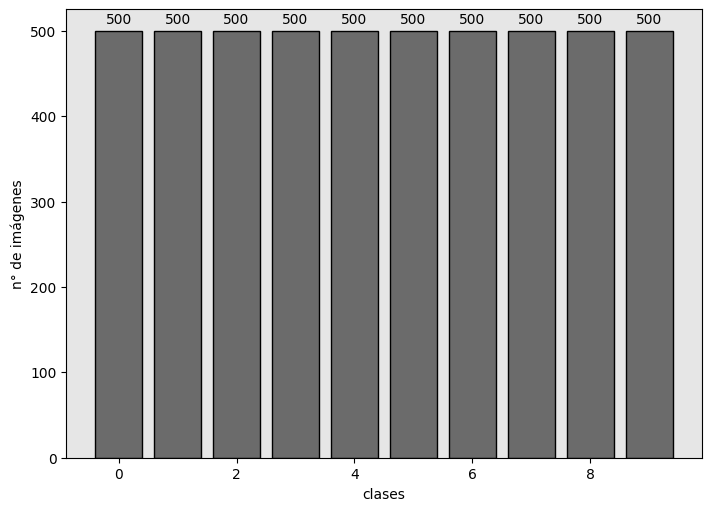

In [ ]:
#selección de un subconjunto de los datos
X_reduced_10classes, y_reduced_10classes = testing_data(X, y, samples_per_class=500)

In [ ]:
#conversión a escala de grises
X_reduced_10classes = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in X_reduced_10classes])

# Agregar una dimensión para el canal
X_reduced_10classes = np.array([np.expand_dims(img, axis=-1) for img in X_reduced_10classes])

#redimensionamiento de las imágenes (32, 32) -> (224, 224)
X_reduced_10classes = np.array([smart_resize(img, (224, 224)) for img in X_reduced_10classes])

print(f"X shape: {X_reduced_10classes.shape}, Y shape: {y_reduced_10classes.shape}")

X shape: (5000, 224, 224, 1), Y shape: (5000,)


In [ ]:
#selección de solo 2 clases
X_reduced_2classes = X_reduced_10classes[np.isin(y_reduced_10classes, [0, 1])]
y_reduced_2classes = y_reduced_10classes[np.isin(y_reduced_10classes, [0, 1])]

print(f"X shape: {X_reduced_2classes.shape}, Y shape: {y_reduced_2classes.shape}")

X shape: (1000, 224, 224, 1), Y shape: (1000,)


## `SIFT feature extractor`

### `Dibujando Keypoints`

In [ ]:
sift = cv2.xfeatures2d.SIFT_create()
kp, des = sift.detectAndCompute(X_reduced_10classes[0], None)
print(f"kp shape: {len(kp)}, des shape: {des.shape}")

kp shape: 41, des shape: (41, 128)


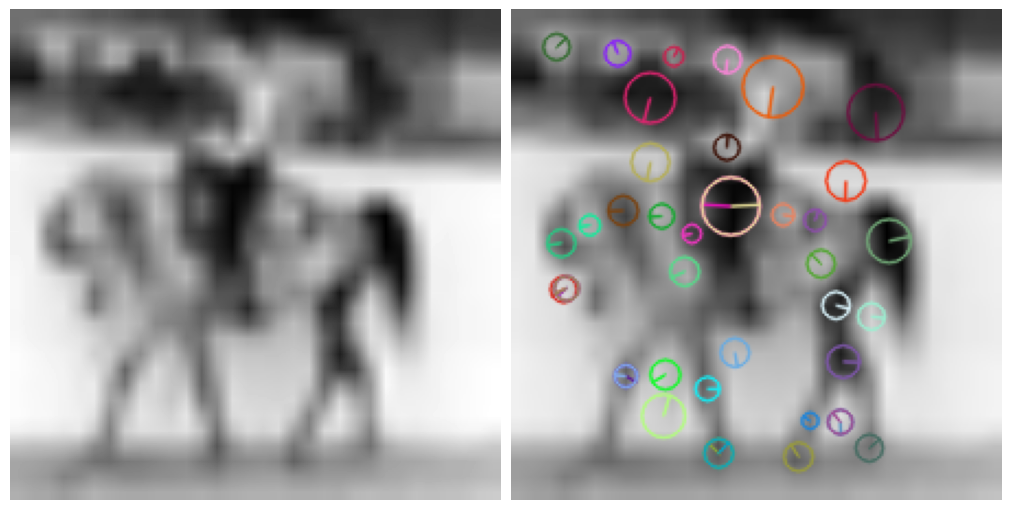

In [ ]:
img_kp = cv2.drawKeypoints(X_reduced_10classes[0], kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axs = plt.subplots(1,2,layout='constrained',figsize=(10,10))
axs[0].imshow(X_reduced_10classes[0], cmap='gray')
# axs[0].set_title('Imagen Original')
axs[0].axis('off')
axs[1].imshow(img_kp)
# axs[1].set_title('Keypoints')
axs[1].axis('off')

plt.savefig('keypointsCIFAR10.pdf', bbox_inches='tight')
plt.show()

### `Vectores de Caracerísticas SIFT`

#### `10 clases`

In [ ]:
start_time = time.time()
sift_feature_vectors_10classes = sift_feature_extractor(
    X_reduced_10classes,
    n_clusters=100,
    feature_vectors_path='feature_vectors/sift_cifar10_10classes.npy'
)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time} segundos")

descriptors_stack shape: (166113, 128)
sift_feature_vectors shape: (5000, 100)
Tiempo de ejecución: 232.78804993629456 segundos


#### `2 clases`

In [ ]:
start_time = time.time()
sift_feature_vectors_2classes = sift_feature_extractor(
    X_reduced_2classes,
    n_clusters=100,
    feature_vectors_path='feature_vectors/sift_cifar10_2classes.npy'
)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time} segundos")

descriptors_stack shape: (31702, 128)
sift_feature_vectors shape: (1000, 100)
Tiempo de ejecución: 38.39469885826111 segundos


### `Clasificación`

#### `MLP 10 classes`

In [ ]:
train_predict(
    x=sift_feature_vectors_10classes,
    y=y_reduced_10classes,
    classifier='mlp',
    classes=10,
    weights_path='weights/SIFTCIFAR10MLP_10Classes',
    write_file='results/SIFTCIFAR10MLP_10Classes.pkl'
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.1264 - f1_score: 0.1255 - loss: 2.3392 - val_accuracy: 0.0975 - val_f1_score: 0.0649 - val_loss: 2.2970
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2637 - f1_score: 0.2580 - loss: 2.0712 - val_accuracy: 0.1600 - val_f1_score: 0.1101 - val_loss: 2.2767
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2995 - f1_score: 0.2931 - loss: 1.9660 - val_accuracy: 0.1737 - val_f1_score: 0.1444 - val_loss: 2.2422
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3333 - f1_score: 0.3285 - loss: 1.8938 - val_accuracy: 0.2075 - val_f1_score: 0.1945 - val_loss: 2.1959
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3374 - f1_score: 0.3348 - loss: 1.8564 - val_accuracy: 0.2350 - val_f1_score: 0.2276 - val_loss: 2.1416
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3675 - f1_score: 0.3643 - loss: 1.8303 - val_accuracy: 0.2488 - val_f1_score: 0.2461 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1393 - f1_score: 0.1387 - loss: 2.3456 - val_accuracy: 0.1325 - val_f1_score: 0.0849 - val_loss: 2.3010
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2585 - f1_score: 0.2487 - loss: 2.0833 - val_accuracy: 0.1538 - val_f1_score: 0.1112 - val_loss: 2.2800
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2988 - f1_score: 0.2926 - loss: 1.9752 - val_accuracy: 0.1800 - val_f1_score: 0.1576 - val_loss: 2.2458
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3107 - f1_score: 0.3085 - loss: 1.9022 - val_accuracy: 0.1975 - val_f1_score: 0.1959 - val_loss: 2.2014
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3408 - f1_score: 0.3353 - loss: 1.8595 - val_accuracy: 0.2250 - val_f1_score: 0.2161 - val_loss: 2.1482
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3629 - f1_score: 0.3576 - loss: 1.8150 - val_accuracy: 0.2325 - val_f1_score: 0.2252 - val_los

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1298 - f1_score: 0.1272 - loss: 2.3358 - val_accuracy: 0.1462 - val_f1_score: 0.0911 - val_loss: 2.2991
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2731 - f1_score: 0.2651 - loss: 2.0455 - val_accuracy: 0.1575 - val_f1_score: 0.1061 - val_loss: 2.2792
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3142 - f1_score: 0.3075 - loss: 1.9566 - val_accuracy: 0.1775 - val_f1_score: 0.1570 - val_loss: 2.2459
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3389 - f1_score: 0.3350 - loss: 1.8865 - val_accuracy: 0.2188 - val_f1_score: 0.2188 - val_loss: 2.1975
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3620 - f1_score: 0.3567 - loss: 1.8385 - val_accuracy: 0.2500 - val_f1_score: 0.2384 - val_loss: 2.1339
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3827 - f1_score: 0.3788 - loss: 1.7983 - val_accuracy: 0.2612 - val_f1_score: 0.2496 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1263 - f1_score: 0.1248 - loss: 2.3594 - val_accuracy: 0.1312 - val_f1_score: 0.0679 - val_loss: 2.2997
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2492 - f1_score: 0.2426 - loss: 2.0819 - val_accuracy: 0.1538 - val_f1_score: 0.1005 - val_loss: 2.2800
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3014 - f1_score: 0.2964 - loss: 1.9660 - val_accuracy: 0.1737 - val_f1_score: 0.1328 - val_loss: 2.2463
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3381 - f1_score: 0.3327 - loss: 1.8986 - val_accuracy: 0.2062 - val_f1_score: 0.1859 - val_loss: 2.1968
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3376 - f1_score: 0.3329 - loss: 1.8544 - val_accuracy: 0.2300 - val_f1_score: 0.2183 - val_loss: 2.1384
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3607 - f1_score: 0.3583 - loss: 1.8154 - val_accuracy: 0.2450 - val_f1_score: 0.2420 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1331 - f1_score: 0.1324 - loss: 2.3310 - val_accuracy: 0.0838 - val_f1_score: 0.0377 - val_loss: 2.3021
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2507 - f1_score: 0.2409 - loss: 2.0639 - val_accuracy: 0.1150 - val_f1_score: 0.0815 - val_loss: 2.2801
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2894 - f1_score: 0.2795 - loss: 1.9720 - val_accuracy: 0.1700 - val_f1_score: 0.1594 - val_loss: 2.2488
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3218 - f1_score: 0.3147 - loss: 1.9116 - val_accuracy: 0.1887 - val_f1_score: 0.1889 - val_loss: 2.2072
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3429 - f1_score: 0.3357 - loss: 1.8666 - val_accuracy: 0.2188 - val_f1_score: 0.2120 - val_loss: 2.1530
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3561 - f1_score: 0.3497 - loss: 1.8235 - val_accuracy: 0.2288 - val_f1_score: 0.2199 - val_los

In [ ]:
with open('results/SIFTCIFAR10MLP_10Classes.pkl', 'rb') as file:
    df_mlp_10classes = pickle.load(file)

df_mlp_10classes

,,accuracy,f1_weighted
0,,0.270,0.260602
1,,0.283,0.278560
2,,0.254,0.238223
3,,0.249,0.239132
4,,0.279,0.275714
5,means,0.267,0.258446


#### `MLP 2 clases`

In [ ]:
train_predict(
    x=sift_feature_vectors_2classes,
    y=y_reduced_2classes,
    classifier='mlp',
    classes=2,
    weights_path='weights/SIFTCIFAR10MLP_2Classes',
    write_file='results/SIFTCIFAR10MLP_2Classes.pkl'
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6182 - f1_score: 0.6182 - loss: 0.6458 - val_accuracy: 0.4062 - val_f1_score: 0.2751 - val_loss: 0.6900
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7613 - f1_score: 0.7606 - loss: 0.4673 - val_accuracy: 0.3688 - val_f1_score: 0.1987 - val_loss: 0.7164
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7834 - f1_score: 0.7835 - loss: 0.4248 - val_accuracy: 0.3688 - val_f1_score: 0.1987 - val_loss: 0.7357
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8134 - f1_score: 0.8135 - loss: 0.4014 - val_accuracy: 0.3688 - val_f1_score: 0.1987 - val_loss: 0.7569
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8331 - f1_score: 0.8330 - loss: 0.3664 - val_accuracy: 0.3688 - val_f1_score: 0.1987 - val_loss: 0.7612
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8623 - f1_score: 0.8624 - loss: 0.3388 - val_accuracy: 0.3688 - val_f1_score: 0.1987 - val_loss: 0.7709
Ep

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.6314 - f1_score: 0.6321 - loss: 0.6468 - val_accuracy: 0.3500 - val_f1_score: 0.1891 - val_loss: 0.6964
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7532 - f1_score: 0.7520 - loss: 0.4715 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7168
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8017 - f1_score: 0.8021 - loss: 0.4170 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7409
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8098 - f1_score: 0.8102 - loss: 0.3817 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7554
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8441 - f1_score: 0.8445 - loss: 0.3442 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7642
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8475 - f1_score: 0.8478 - loss: 0.3346 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7791
Ep

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.6734 - f1_score: 0.6742 - loss: 0.6332 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7059
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7781 - f1_score: 0.7780 - loss: 0.4458 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7390
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7912 - f1_score: 0.7918 - loss: 0.4037 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7589
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8552 - f1_score: 0.8555 - loss: 0.3660 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7776
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8428 - f1_score: 0.8433 - loss: 0.3543 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7872
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8435 - f1_score: 0.8440 - loss: 0.3246 - val_accuracy: 0.3438 - val_f1_score: 0.1759 - val_loss: 0.7919
Ep

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6450 - f1_score: 0.6454 - loss: 0.6309 - val_accuracy: 0.3375 - val_f1_score: 0.1703 - val_loss: 0.7040
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7977 - f1_score: 0.7975 - loss: 0.4278 - val_accuracy: 0.3375 - val_f1_score: 0.1703 - val_loss: 0.7404
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8201 - f1_score: 0.8204 - loss: 0.3771 - val_accuracy: 0.3375 - val_f1_score: 0.1703 - val_loss: 0.7729
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8403 - f1_score: 0.8406 - loss: 0.3470 - val_accuracy: 0.3375 - val_f1_score: 0.1703 - val_loss: 0.7942
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8763 - f1_score: 0.8765 - loss: 0.3022 - val_accuracy: 0.3375 - val_f1_score: 0.1703 - val_loss: 0.8067
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8849 - f1_score: 0.8851 - loss: 0.2897 - val_accuracy: 0.3375 - val_f1_score: 0.1703 - val_loss: 0.8181

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6640 - f1_score: 0.6642 - loss: 0.6183 - val_accuracy: 0.4000 - val_f1_score: 0.2286 - val_loss: 0.6930
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8025 - f1_score: 0.8024 - loss: 0.4404 - val_accuracy: 0.4000 - val_f1_score: 0.2286 - val_loss: 0.7026
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8148 - f1_score: 0.8146 - loss: 0.4021 - val_accuracy: 0.4000 - val_f1_score: 0.2286 - val_loss: 0.7158
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8424 - f1_score: 0.8425 - loss: 0.3506 - val_accuracy: 0.4000 - val_f1_score: 0.2286 - val_loss: 0.7210
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8094 - f1_score: 0.8095 - loss: 0.3613 - val_accuracy: 0.4000 - val_f1_score: 0.2286 - val_loss: 0.7254
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8513 - f1_score: 0.8513 - loss: 0.3483 - val_accuracy: 0.4000 - val_f1_score: 0.2286 - val_loss: 0.7269
Ep

In [ ]:
with open('results/SIFTCIFAR10MLP_2Classes.pkl', 'rb') as file:
    df_mlp_2classes = pickle.load(file)

df_mlp_2classes

,,accuracy,f1_weighted
0,,0.500,0.333333
1,,0.505,0.344349
2,,0.500,0.333333
3,,0.500,0.333333
4,,0.505,0.344349
5,means,0.502,0.337740


#### `RFC 10 clases`

In [ ]:
train_predict(
    x=sift_feature_vectors_10classes,
    y=y_reduced_10classes,
    classifier='rfc',
    classes=None,
    weights_path=None,
    write_file='results/SIFTCIFAR10RFC_10Classes.pkl'
)

In [ ]:
with open('results/SIFTCIFAR10RFC_10Classes.pkl', 'rb') as file:
    df_rfc_10classes = pickle.load(file)

df_rfc_10classes

,,accuracy,f1_weighted
0,,0.2970,0.288742
1,,0.3020,0.295543
2,,0.2720,0.265098
3,,0.2620,0.253896
4,,0.2840,0.276536
5,means,0.2834,0.275963


#### `RFC 2 clases`

In [ ]:
train_predict(
    x=sift_feature_vectors_2classes,
    y=y_reduced_2classes,
    classifier='rfc',
    classes=None,
    weights_path=None,
    write_file='results/SIFTCIFAR10RFC_2Classes.pkl'
)

In [ ]:
with open('results/SIFTCIFAR10RFC_2Classes.pkl', 'rb') as file:
    df_rfc_2classes = pickle.load(file)

df_rfc_2classes

,,accuracy,f1_weighted
0,,0.825,0.824645
1,,0.790,0.788647
2,,0.810,0.809829
3,,0.820,0.819838
4,,0.755,0.754257
5,means,0.800,0.799443
